<a href="https://colab.research.google.com/github/arelkeselbri/gsi073/blob/main/aula6_retrieval_augmented_generation_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 6: Introdução a RAG (Retrieval-Augmented Generation)

Objetivos:

- Entender o pipeline completo de um sistema RAG
- Implementar:
  - Chunking
  - Geração de embeddings
  - Busca vetorial por similaridade
  - Geração de resposta condicionada ao contexto recuperado
- Analisar como a recuperação influencia a qualidade da resposta


Nesta aula vamos usar o seguinte roteiro prático:

1. Criar uma mini base de conhecimento (docs).
2. Fazer *chunking* (segmentação) para obter unidades recuperáveis.
3. Gerar embeddings e implementar uma busca vetorial simples.
4. Montar o *contexto* (augmentation) com os chunks mais relevantes.
5. Passar o contexto para um modelo gerador (generator) e obter uma resposta (*RAG completo*).


## 1) Setup do ambiente


In [6]:
# Se necessário, instale as seguintes dependências:
# !pip install -U sentence-transformers transformers torch scikit-learn numpy pandas matplotlib

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch


## 2) Mini Base de Conhecimento


In [19]:
# Mini base de conhecimento (exemplo didático).
# Dica: substitua por trechos do seu domínio (FAQ, políticas, docs, etc.).

docs = [
 #   {
 #       "id": "doc1",
 #       "text": '''
 #       A empresa utiliza arquitetura baseada em microserviços.
   #     Todos os serviços devem se comunicar via API REST autenticada.
   #     O deploy é realizado usando Kubernetes.
   #     '''
   # },
   # {
   #     "id": "doc2",
   #     "text": '''
   #     O modelo principal de NLP é baseado em transformers decoder-only.
   #     Para tarefas de busca semântica utilizamos modelos encoder-only.
   #     Embeddings são armazenados em banco vetorial.
   #     '''
   # },
   # {
   #     "id": "doc3",
   #     "text": '''
   #     A política de segurança exige autenticação multifator.
   #     Tokens JWT devem expirar em no máximo 1 hora.
   #     Logs devem ser armazenados por 90 dias.
   #     '''
   # },
    {
        "id": "doc4",
        "text": '''
        Um RPG de fantasia épica onde o jogador é o último Guardião de um reino assolado por uma Sombra ancestral. Suas escolhas definem o destino dos deuses e mortais.
        Um RPG de ação focado em combate tático de espadas. Assuma o papel de um ronin em busca de redenção no Japão feudal pós-guerra civil.
        Um RPG de mundo aberto onde a caça e domesticação de dragões é a chave para salvar o mundo da extinção.
        '''
    },
    {
        "id": "doc5",
        "text": '''
        Um simulador de economia onde você compra, vende e troca mercadorias em uma movimentada cidade medieval.
        Um simulador de jardinagem zen onde o objetivo é cultivar e descobrir espécies raras de plantas em um mundo mágico em constante mudança.
        Um relaxante simulador de forja em pixel art. Colete materiais, aprimore suas ferramentas e crie armas lendárias sob encomenda para heróis e vilões.
        '''
    },

    {
        "id": "doc6",
        "text": '''
        Um jogo de estratégia em tempo real. Lidere um clã viking, construa drakkares e faça incursões em terras estrangeiras para glória e riqueza.
        Um jogo de xadrez tático onde as peças são unidades com habilidades especiais, adicionando uma camada de estratégia de ficção científica.
        Um jogo de estratégia 4X em um pequeno universo procedural. Conquiste planetas, pesquise tecnologias e negocie com raças alienígenas.
        '''
    },

    {
        "id": "doc7",
        "text": '''
        Um jogo de luta 1v1 onde os jogadores lançam feitiços complexos em tempo real para derrotar seus oponentes.
        Um FPS imersivo em um mundo distópico. Jogue como um mercenário cibernético que luta contra megacorporações opressoras.
        Um jogo de luta 2D clássico com movimentos fluidos e um sistema de combate baseado em combos profundos.
        '''
    },

    {
        "id": "doc8",
        "text": '''
        Um jogo de plataforma de quebra-cabeças onde o protagonista usa piadas e truques para superar guardas e armadilhas.
        Um jogo de plataforma 2D com a mecânica de manipulação temporal. O protagonista pode saltar para trás ou para frente no tempo para resolver quebra-cabeças complexos.
        Um jogo de plataforma encantador. Jogue como um cavaleiro diminuto que deve resgatar princesas e heróis presos em livros de histórias.
        '''
    },

]


## 3) Chunking (segmentação) - construção de contexto

Nesta aula, vamos usar sentenças como chunks (simples e didático).  
Em produção, você normalmente usa chunking por **tamanho** (tokens/caracteres) + **overlap**.


In [21]:
def split_sentences_pt(text: str) -> list[str]:
    # Segmentação simplificada (por ponto).
    return [s.strip() for s in text.split(".") if len(s.strip()) > 0]

rows = []
for doc in docs:
    sentences = split_sentences_pt(doc["text"])
    for sent in sentences:
        rows.append({
            "doc_id": doc["id"],
            "sentence": sent
        })

df = pd.DataFrame(rows)
df


,doc_id,sentence
0,doc4,Um RPG de fantasia épica onde o jogador é o úl...
1,doc4,Suas escolhas definem o destino dos deuses e m...
2,doc4,Um RPG de ação focado em combate tático de esp...
3,doc4,Assuma o papel de um ronin em busca de redençã...
4,doc4,Um RPG de mundo aberto onde a caça e domestica...
5,doc5,"Um simulador de economia onde você compra, ven..."
6,doc5,Um simulador de jardinagem zen onde o objetivo...
7,doc5,Um relaxante simulador de forja em pixel art
8,doc5,"Colete materiais, aprimore suas ferramentas e ..."
9,doc6,Um jogo de estratégia em tempo real


## 4) Gerar embeddings (Retriever, R do RAG)

Usaremos um modelo encoder-only do SentenceTransformers para gerar embeddings dos chunks.


In [23]:
model_emb = SentenceTransformer("all-MiniLM-L6-v2")

sentences = df["sentence"].tolist()
embeddings = model_emb.encode(sentences)

df["embedding"] = list(embeddings)
df.head()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,doc_id,sentence,embedding
0,doc4,Um RPG de fantasia épica onde o jogador é o úl...,"[-0.0066342973, 0.097590685, -0.09442247, -0.0..."
1,doc4,Suas escolhas definem o destino dos deuses e m...,"[-0.028100783, 0.06320462, -0.026386172, -0.07..."
2,doc4,Um RPG de ação focado em combate tático de esp...,"[0.04680367, 0.029490039, -0.0776536, -0.05667..."
3,doc4,Assuma o papel de um ronin em busca de redençã...,"[-0.070987426, 0.0472475, -0.09057377, -0.0824..."
4,doc4,Um RPG de mundo aberto onde a caça e domestica...,"[0.029150467, 0.060611542, -0.061241996, 0.007..."


## 5) Busca vetorial por similaridade (R do RAG)

Implementação minimalista com similaridade cosseno.  
(Em produção, isso vai para um índice/banco vetorial: FAISS, Milvus, Pinecone, Weaviate, pgvector, etc.)


In [24]:
def retrieve(query: str, top_k: int = 3) -> pd.DataFrame:
    query_emb = model_emb.encode([query])
    matrix = np.vstack(df["embedding"].values)

    sims = cosine_similarity(query_emb, matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]

    results = df.iloc[top_idx].copy()
    results["score"] = sims[top_idx]
    return results

query = ""
retrieve(query, top_k=3)


,doc_id,sentence,embedding,score
7,doc5,Um relaxante simulador de forja em pixel art,"[-0.022878936, 0.032650243, 0.007907981, -0.07...",0.160736
21,doc8,Um jogo de plataforma encantador,"[-0.02182939, 0.05675253, -0.076906696, -0.067...",0.157909
9,doc6,Um jogo de estratégia em tempo real,"[-0.05310914, 0.06324267, -0.007009327, 0.0118...",0.137108


## 6) Montando o contexto (Augmentation, A do RAG)

Agora agregamos os chunks recuperados em um bloco de texto que será injetado no prompt.


In [ ]:
def build_context(query: str, top_k: int = 3) -> str:
    retrieved = retrieve(query, top_k)
    context = "\n".join(retrieved["sentence"].tolist())
    return context

query = "Jogos de simulador famosos"
context = build_context(query, top_k=5)
print(context)


Um relaxante simulador de forja em pixel art
Um jogo de plataforma encantador
Um jogo de estratégia em tempo real


## 7) Parte gerativa (Generation, G do RAG)

Aqui usamos um modelo causal pequeno para fins didáticos. Troque o distilgpt2 para o gemma 3 para melhores resultados.


In [28]:
model_name = "distilgpt2" # Modelo pequeno para teste rápido
#model_name = "google/gemma-3-270m" # De melhor qualidade, mas download de 0.5G

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_gen = AutoModelForCausalLM.from_pretrained(model_name)

# distilgpt-2 não tem pad_token necessário para a geração
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

## 8) Pipeline RAG simples

1. Recupera chunks (Retriever)  
2. Monta contexto (Augmentation)  
3. Gera resposta condicionada (Generator)


In [33]:
def rag_answer(query: str, top_k: int = 5, max_tokens: int = 150) -> str:
    context = build_context(query, top_k)

    prompt = f"""Responda à pergunta usando apenas o contexto abaixo.

Contexto:
{context}

Pergunta:
{query}

Resposta:
"""

    inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        outputs = model_gen.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

rag_answer("Estratégia e simulação", top_k=5)


'Responda à pergunta usando apenas o contexto abaixo.\n\nContexto:\nUm jogo de estratégia em tempo real\nUm jogo de estratégia 4X em um pequeno universo procedural\nUm jogo de xadrez tático onde as peças são unidades com habilidades especiais, adicionando uma camada de estratégia de ficção científica\nUm jogo de plataforma encantador\nUm FPS imersivo em um mundo distópico\n\nPergunta:\nEstratégia e simulação\n\nResposta:\nEstratégia e simulação\nResposta:\nEstratégia e simulação\nResposta:\nEstratégia e simulação\nResposta:\nEstratégia e simulação\nResposta:\nEstratégia e simulação\nResposta:\nEstratégia e simulação\nResposta:\nEstratégia e simulação\nResposta:\nEstratégia e simulação\nResposta:\nEstratégia e simulação\nRespost'

## 9) Visualizando similaridade (conexão com Embeddings)

Vamos projetar os embeddings em 2D com PCA para observar agrupamentos.


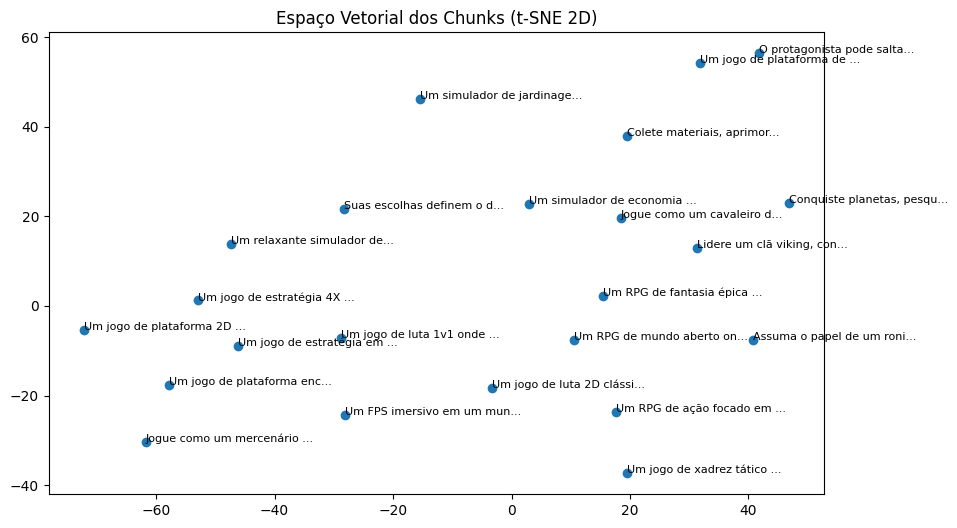

In [30]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Import TSNE
import matplotlib.pyplot as plt

X = np.vstack(df["embedding"].values)

# Use t-SNE instead of PCA
ts = TSNE(n_components=2, random_state=42, perplexity=5) # Added random_state for reproducibility and fixed perplexity
X2 = ts.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X2[:, 0], X2[:, 1])

for i, txt in enumerate(df["sentence"]):
    plt.annotate(txt[:25] + ("..." if len(txt) > 25 else ""), (X2[i, 0], X2[i, 1]), fontsize=8)

plt.title("Espaço Vetorial dos Chunks (t-SNE 2D)") # Update title
plt.show()

## 10) Experimentos

Tente rodar as células abaixo e discutir os resultados.

- O que acontece se `top_k = 1`?
- E se aumentarmos para `top_k = 5`?
- Faça uma pergunta fora do domínio da base (para ver como o sistema se comporta).
- Modifique os documentos e observe o impacto na resposta.
